In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import sklearn
from xgboost import XGBRegressor


In [2]:
# Load Data
df = pd.read_csv("../data/processed/feature_data.csv")
df['date'] = pd.to_datetime(df['date'])

In [3]:
# Split Data (not random splitting since this is time series data)
split_date = "2017-01-01"

train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

In [4]:
# Define Targets and Features
FEATURES = [
    'store', 'item',
    'day_of_week', 'month', 'year', 'day_of_month',
    'lag_1', 'lag_7', 'lag_14', 'lag_28', 'lag_56', 'lag_84',
    'rolling_mean_7', 'rolling_std_7',
    'rolling_mean_14', 'rolling_mean_28',
    'rolling_max_7',
    'diff_1'
]

TARGET = 'sales'

In [5]:
# Train Baseline Model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    train[FEATURES],
    train[TARGET]
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [6]:
# Perform Predictions
preds = model.predict(test[FEATURES])

In [7]:
# Evaluate Model
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test[TARGET], preds)

print("MAE:", mae)

MAE: 6.105166912078857


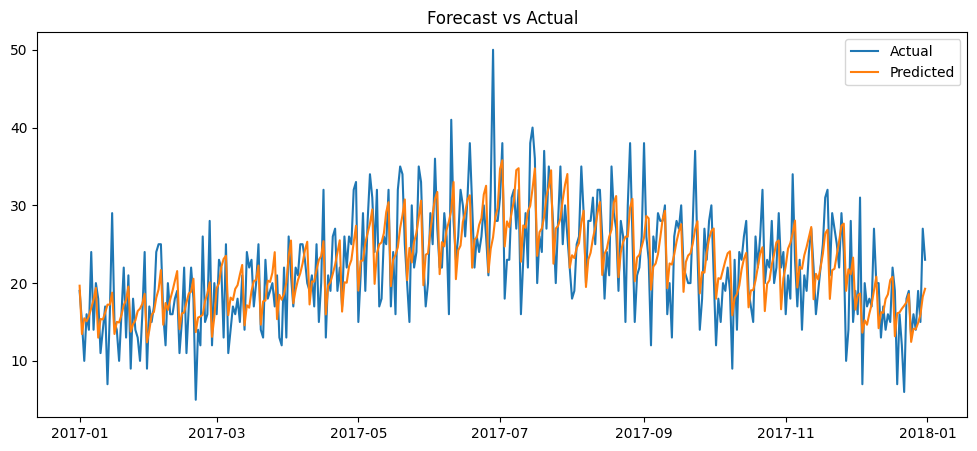

In [8]:
# Visualize Predictions
import matplotlib.pyplot as plt

sample_test = test[(test['store']==1) & (test['item']==1)].copy()
sample_test['pred'] = model.predict(sample_test[FEATURES])

plt.figure(figsize=(12,5))
plt.plot(sample_test['date'], sample_test['sales'], label='Actual')
plt.plot(sample_test['date'], sample_test['pred'], label='Predicted')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()

# Experiments

##  1. Check Volatility of Predictions

In [9]:
actual_std = np.std(test[TARGET])
pred_std = np.std(preds)

print("Actual STD:", actual_std)
print("Predicted STD:", pred_std)

Actual STD: 31.552610977862994
Predicted STD: 30.403118


## 2. Mean Absolute Changes

In [10]:
actual_diff = np.mean(np.abs(np.diff(test[TARGET])))
pred_diff = np.mean(np.abs(np.diff(preds)))

print("Actual Avg Change:", actual_diff)
print("Predicted Avg Change:", pred_diff)

Actual Avg Change: 11.298708486073897
Predicted Avg Change: 6.8725505


## 3. Peak Captures

In [11]:
print("Actual Max:", test[TARGET].max())
print("Predicted Max:", preds.max())

print("Actual Min:", test[TARGET].min())
print("Predicted Min:", preds.min())

Actual Max: 231
Predicted Max: 194.98006
Actual Min: 2
Predicted Min: 8.201752


## 4. Correlation

In [12]:
corr = np.corrcoef(test[TARGET], preds)[0,1]
print("Correlation:", corr)

Correlation: 0.9679088914029917


## 5. Residual Analysis

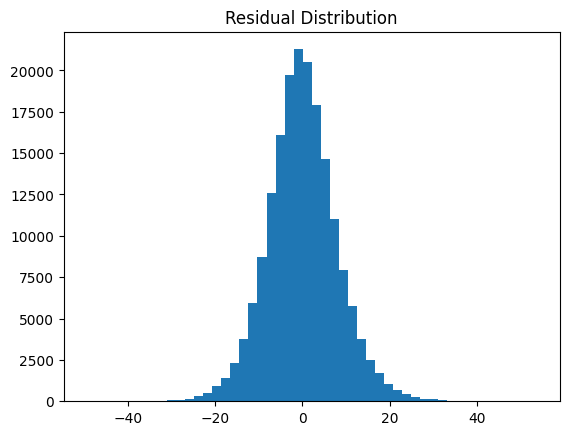

In [13]:
residuals = test[TARGET] - preds

import matplotlib.pyplot as plt

plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

In [14]:
print(train[['sales', 'diff_1', 'lag_1']].head())

   sales  diff_1  lag_1
0     16    -6.0   13.0
1     11     2.0   16.0
2     13    -6.0   11.0
3     17    -8.0   13.0
4     19    -4.0   17.0
